# Pipeline IMRaD — Dataset Consolidado

**Dataset:** `data/RawDatasetsV2/DatasetAnotacionManual_Consolidado.xlsx` (1600 fragmentos).
**Tarea:** clasificar en **8 clases** (INTRO, BACK, METH, RES, DISC, CONC, CONTR, LIM); el **4c** se obtiene por agrupación.
**Métrica:** F1-macro (8c y 4c).

## Estructura del notebook
1. Setup
2. Carga de datos
3. EDA
4. Split 80/10/10 por documento
5. Helpers de evaluación
6. Prompts (v1, v2)
7. Modelos
    - 7.1 TF-IDF + LR
    - 7.2 SciBETO (Head+Tail)
    - 7.3 Qwen3-8B (MLX, sin LoRA)
    - 7.4 Gemini 3-Flash
    - *(añadir más modelos como nuevas subsecciones aquí)*
8. Comparativa final
9. Conclusiones

## 1. Setup

In [1]:
import os, sys, json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Cargar .env (GEMINI_API_KEY)
try:
    from dotenv import load_dotenv
    load_dotenv(ROOT / '.env')
except Exception:
    pass

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_XLSX = ROOT / 'data/RawDatasetsV2/DatasetAnotacionManual_Consolidado.xlsx'
SPLIT_DIR = ROOT / 'data/splits/imrad8_consolidado'
REPORTS_DIR = ROOT / 'reports/entrega3/consolidado'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LABELS_8C = ['INTRO','BACK','METH','RES','DISC','CONC','CONTR','LIM']
CODE2ID_8 = {c:i for i,c in enumerate(LABELS_8C)}
MAP_8_TO_4 = {0:0, 1:0, 2:1, 3:2, 4:3, 5:3, 6:3, 7:3}
LABELS_4C = ['I','M','R','D']

RESULTADOS = []  # se llena con cada modelo en la sección 7

print('Root:', ROOT, '| Excel existe:', DATA_XLSX.exists())

Root: /Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish | Excel existe: True


## 2. Carga de datos

In [2]:
from src.data.annotated_loader import load_annotated_xlsx, preprocess

ds = load_annotated_xlsx(DATA_XLSX)
ds = preprocess(ds, text_column='text')
df = ds.to_pandas()
df['imrad4_label'] = df['imrad8_label'].map(MAP_8_TO_4)
print('Filas:', len(df), '| Documentos:', df['documento_id'].nunique())
df.head(3)

Limpiando textos: 100%|██████████| 1587/1587 [00:00<00:00, 24770.62 examples/s]

Filas: 1587 | Documentos: 932


,text,label_code,imrad8_label,id,chunk_id,documento_id,num_palabras,encabezado_seccion,imrad4_label
0,Población finita es el conjunto del que se con...,METH,2,1,doc_86570956_chk013,86570956.txt,366,O,1
1,Algunos de los motivos de insatisfacción más f...,LIM,7,2,doc_102544477_chk012,102544477.txt,309,Limitaciones,3
2,"como parte de esta metodología: comunicación, ...",LIM,7,3,doc_74592414_chk006,74592414.txt,733,limitaciones,3


## 3. EDA

### 3.1 Volumen y cobertura

In [3]:
n_frag = len(df)
n_doc = df['documento_id'].nunique()
frag_por_doc = df.groupby('documento_id').size()
print(f'Fragmentos: {n_frag}')
print(f'Documentos: {n_doc}')
print(f'Fragmentos/documento — media={frag_por_doc.mean():.1f}, mediana={frag_por_doc.median():.0f}, min={frag_por_doc.min()}, max={frag_por_doc.max()}')

Fragmentos: 1587
Documentos: 932
Fragmentos/documento — media=1.7, mediana=1, min=1, max=5


### 3.2 Distribución de etiquetas (8c y 4c)

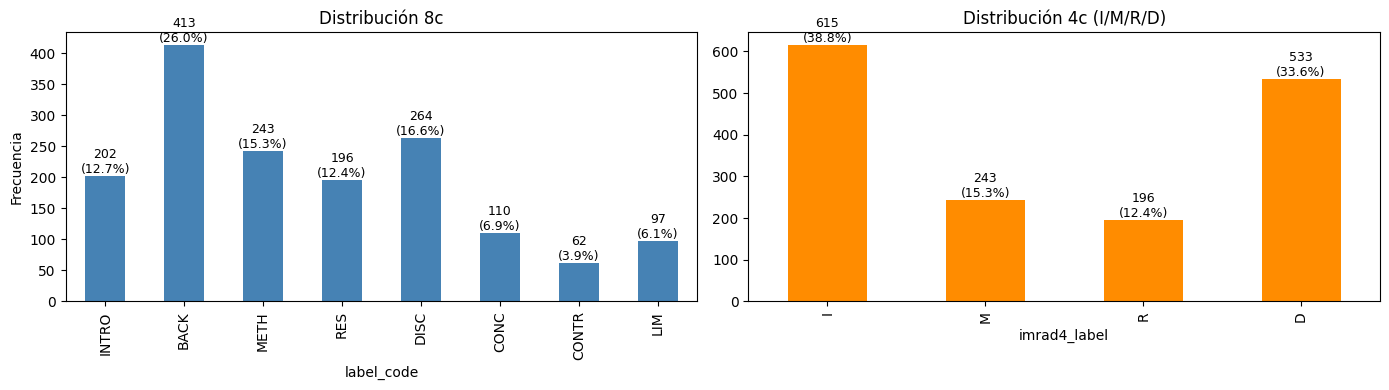

Ratio max/min 8c: 6.66
Ratio max/min 4c: 3.14


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
c8 = df['label_code'].value_counts().reindex(LABELS_8C)
c8.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución 8c'); axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(c8.values):
    axes[0].text(i, v, f'{v}\n({v/n_frag*100:.1f}%)', ha='center', va='bottom', fontsize=9)

c4 = df['imrad4_label'].map(dict(enumerate(LABELS_4C))).value_counts().reindex(LABELS_4C)
c4.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Distribución 4c (I/M/R/D)')
for i, v in enumerate(c4.values):
    axes[1].text(i, v, f'{v}\n({v/n_frag*100:.1f}%)', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print('Ratio max/min 8c:', f'{c8.max()/c8.min():.2f}')
print('Ratio max/min 4c:', f'{c4.max()/c4.min():.2f}')

**Análisis:** clases minoritarias (típicamente CONTR y LIM) → reportar **F1-macro** y usar `class_weight='balanced'` durante el entrenamiento.

### 3.3 Longitud de fragmentos — justificación de Head+Tail

In [5]:
df['est_tokens'] = (df['num_palabras'] * 1.3).round().astype(int)
print('Palabras por fragmento:')
print(df['num_palabras'].describe(percentiles=[.5, .75, .9, .95, .99]).round(1).to_string())
print('\nTokens estimados (×1.3):')
print(df['est_tokens'].describe(percentiles=[.5, .75, .9, .95, .99]).round(1).to_string())
p95_tok = df['est_tokens'].quantile(0.95)
frac_over_512 = (df['est_tokens'] > 512).mean()
print(f'\nFracción con est_tokens > 512: {frac_over_512:.1%} | p95={p95_tok:.0f}')

Palabras por fragmento:
count    1587.0
mean      526.3
std       177.1
min       250.0
50%       548.0
75%       676.0
90%       699.0
95%       800.7
99%       917.5
max       996.0

Tokens estimados (×1.3):
count    1587.0
mean      684.1
std       230.3
min       325.0
50%       712.0
75%       879.0
90%       909.0
95%      1040.7
99%      1193.0
max      1295.0

Fracción con est_tokens > 512: 69.4% | p95=1041


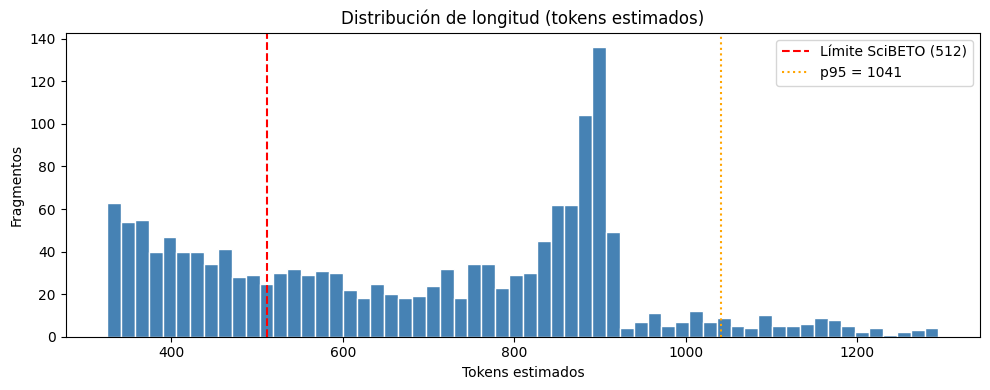

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['est_tokens'], bins=60, color='steelblue', edgecolor='white')
ax.axvline(512, color='red', ls='--', label='Límite SciBETO (512)')
ax.axvline(p95_tok, color='orange', ls=':', label=f'p95 = {p95_tok:.0f}')
ax.set_xlabel('Tokens estimados'); ax.set_ylabel('Fragmentos')
ax.set_title('Distribución de longitud (tokens estimados)')
ax.legend(); plt.tight_layout(); plt.show()

**Justificación de Head+Tail (256+256):**

1. **Límite del encoder:** SciBETO usa BERT con `max_position_embeddings = 512`.
2. **Si p95 supera 512 tokens**, parte de los fragmentos se trunca. La estrategia por defecto (truncar la cola) descarta el cierre.
3. **Hipótesis lingüística:** la señal retórica en textos científicos en español tiende a concentrarse en (a) la **frase tópico** al inicio ("Este estudio busca…", "Los métodos empleados…") y (b) la **frase de cierre** ("Se concluye que…", "Se observó que…"). Truncar el centro pierde menos que truncar el final.
4. **Estrategia adoptada:** primeros 256 tokens + últimos 256 tokens, totalizando ≤ 512 y preservando apertura–cierre.

Aplica solo a SciBETO. TF-IDF y LLMs no se ven afectados.

### 3.4 Cobertura por documento

In [7]:
clases_por_doc = df.groupby('documento_id')['label_code'].nunique()
print('Clases distintas por documento:')
print(clases_por_doc.describe().round(1).to_string())
print(f'\nDocumentos con ≥6 clases: {(clases_por_doc>=6).sum()} de {n_doc}')
print(f'Documentos con solo 1 clase: {(clases_por_doc==1).sum()}')

Clases distintas por documento:
count    932.0
mean       1.2
std        0.5
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        4.0

Documentos con ≥6 clases: 0 de 932
Documentos con solo 1 clase: 768


### 3.5 Calidad — nulos, duplicados, etiquetas

In [8]:
print('Nulos por columna:')
print(df.isna().sum()[df.isna().sum() > 0].to_string() or '  (ninguno)')
print(f'\nTextos duplicados exactos: {df["text"].duplicated().sum()}')
print(f'\nEtiquetas únicas: {sorted(df["label_code"].unique())}')
print('Coincide con esquema 8c:', set(df['label_code']) <= set(LABELS_8C))

Nulos por columna:
encabezado_seccion    200

Textos duplicados exactos: 0

Etiquetas únicas: ['BACK', 'CONC', 'CONTR', 'DISC', 'INTRO', 'LIM', 'METH', 'RES']
Coincide con esquema 8c: True


### 3.6 Conclusiones del EDA

- **Volumen:** N≈1600, suficiente para fine-tuning de encoder mediano y prompting.
- **Desbalance 8c:** justifica F1-macro y class weights.
- **Longitud:** justifica Head+Tail (256+256) en SciBETO.
- **Cobertura por documento:** split **por `documento_id`** para evitar fuga.
- **Calidad:** sin etiquetas fuera de esquema.

## 4. Split 80/10/10 por documento

La propuesta exige *split sin solapamiento a nivel de documento* y *≥10% para evaluación final*. **80/10/10** cumple ambos. Estratificación por la **clase dominante** del documento.

In [9]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

doc_dom = df.groupby('documento_id')['imrad8_label'].agg(lambda s: s.value_counts().idxmax())
docs = doc_dom.index.to_numpy(); strat = doc_dom.values

docs_trainval, docs_test, strat_tv, _ = train_test_split(
    docs, strat, test_size=0.10, random_state=SEED, stratify=strat)
docs_train, docs_val = train_test_split(
    docs_trainval, test_size=1/9, random_state=SEED, stratify=strat_tv)

split_map = {d:'train' for d in docs_train}
split_map.update({d:'val' for d in docs_val})
split_map.update({d:'test' for d in docs_test})
df['split'] = df['documento_id'].map(split_map)

train_df = df[df['split']=='train'].reset_index(drop=True)
val_df   = df[df['split']=='val'].reset_index(drop=True)
test_df  = df[df['split']=='test'].reset_index(drop=True)

print(df['split'].value_counts())
print('\nDocs por split:', {k:int(v) for k,v in df.groupby('split')['documento_id'].nunique().items()})
for sp in ['train','val','test']:
    print(f'\n{sp}: {len(df[df.split==sp])} fragmentos')
    print(df[df['split']==sp]['label_code'].value_counts().reindex(LABELS_8C).to_string())

split
train    1279
val       156
test      152
Name: count, dtype: int64

Docs por split: {'test': 94, 'train': 744, 'val': 94}

train: 1279 fragmentos
label_code
INTRO    162
BACK     342
METH     193
RES      158
DISC     214
CONC      88
CONTR     50
LIM       72

val: 156 fragmentos
label_code
INTRO    20
BACK     37
METH     24
RES      19
DISC     25
CONC     11
CONTR     6
LIM      14

test: 152 fragmentos
label_code
INTRO    20
BACK     34
METH     26
RES      19
DISC     25
CONC     11
CONTR     6
LIM      11


In [10]:
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
ds_dict = DatasetDict({
    sp: Dataset.from_pandas(df[df['split']==sp].drop(columns=['split']).reset_index(drop=True),
                            preserve_index=False)
    for sp in ['train','val','test']
})
ds_dict.save_to_disk(str(SPLIT_DIR))
print('Split guardado en', SPLIT_DIR)

Saving the dataset (1/1 shards): 100%|██████████| 152/152 [00:00<00:00, 64619.32 examples/s]

Split guardado en /Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/data/splits/imrad8_consolidado


## 5. Helpers de evaluación

In [11]:
from sklearn.metrics import f1_score
import re, json as _json

# Mapeo de nombres completos en español → id
_FULL_NAME_TO_ID = {
    'introduccion': 0, 'introducción': 0,
    'antecedentes': 1,
    'metodologia': 2, 'metodología': 2,
    'resultados': 3,
    'discusion': 4, 'discusión': 4,
    'conclusiones': 5,
    'contribuciones': 6,
    'limitaciones': 7,
}

def parsear_respuesta(s: str) -> int:
    """Extrae id IMRaD-8 de texto libre, JSON o código corto. Devuelve -1 si no reconoce."""
    if not s:
        return -1
    # 1. Intentar JSON {"label": "METH"} o {"label": "Metodología"}
    try:
        j = _json.loads(s.strip())
        raw = str(j.get('label', '')).strip()
        if raw.upper() in CODE2ID_8:
            return CODE2ID_8[raw.upper()]
        key = raw.lower().replace('ó','o').replace('ó','o').replace('é','e').replace('ú','u').replace('í','i').replace('á','a')
        if key in _FULL_NAME_TO_ID:
            return _FULL_NAME_TO_ID[key]
    except Exception:
        pass
    # 2. Buscar código corto (INTRO, BACK, METH, …)
    su = s.upper()
    for code in LABELS_8C:
        if re.search(rf'\b{code}\b', su):
            return CODE2ID_8[code]
    # 3. Buscar nombre completo en español
    sl = s.lower()
    for name, idx in _FULL_NAME_TO_ID.items():
        if name in sl:
            return idx
    return -1

def evaluar(y_true, y_pred, nombre):
    """F1-macro 8c, F1-macro 4c y per-class F1 8c.

    Predicciones inválidas (-1) se mapean a clase fantasma y penalizan el F1.
    """
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    n_invalid = int((y_pred == -1).sum())
    y_pred_8 = np.where(y_pred == -1, 8, y_pred)
    y_true_4 = np.array([MAP_8_TO_4[int(i)] for i in y_true])
    y_pred_4 = np.array([MAP_8_TO_4.get(int(i), 4) for i in y_pred])
    res = {
        'modelo': nombre,
        'f1m_8c': f1_score(y_true, y_pred_8, average='macro', zero_division=0),
        'f1m_4c': f1_score(y_true_4, y_pred_4, average='macro', zero_division=0),
        'per_class_8c': f1_score(y_true, y_pred_8, average=None, labels=list(range(8)), zero_division=0).tolist(),
        'n_invalid': n_invalid,
    }
    RESULTADOS.append(res)
    inv = f' | invalidas={n_invalid}' if n_invalid else ''
    print(f"{nombre}: F1m 8c={res['f1m_8c']:.4f} | F1m 4c={res['f1m_4c']:.4f}{inv}")
    return res


## 6. Prompts (v1, v2)

In [ ]:

# -- Prompt v1: Zero-shot con reglas de prioridad --
_ZERO_SHOT_TEMPLATE = """\
Eres un motor de clasificación estricto para fragmentos de artículos científicos en español según la taxonomía retórica IMRaD-8.

Responde con UNA SOLA PALABRA: el código exacto de la etiqueta.
Códigos válidos: INTRO, BACK, METH, RES, DISC, CONC, CONTR, LIM

Definiciones (función discursiva dominante):
- INTRO: planteamiento del problema, motivación, objetivo del estudio.
- BACK: marco teórico y literatura previa.
- METH: diseño, procedimiento, instrumentos, análisis.
- RES: hallazgos y resultados descriptivos.
- DISC: interpretación y comparación con literatura.
- CONC: cierre y síntesis final.
- CONTR: contribución/aporte original explícito.
- LIM: limitaciones y trabajo futuro.

Prioridad: LIM > CONTR > CONC > DISC > RES > METH > BACK > INTRO

Fragmento:
"""
{text}
"""

Etiqueta (solo el código):"""

def prompt_v1(texto: str) -> str:
    return _ZERO_SHOT_TEMPLATE.format(text=texto.strip())


# -- Prompt v2: instruction-only --
_V2_HEADER = """\
Eres un motor de clasificación estricto para fragmentos de artículos científicos en español según la taxonomía retórica IMRaD-8.

Responde con UNA SOLA PALABRA: el código exacto de la etiqueta.
Códigos válidos: INTRO, BACK, METH, RES, DISC, CONC, CONTR, LIM

Definiciones (función discursiva dominante):
- INTRO — Problema, motivación, objetivos.
- BACK — Literatura previa con citas explícitas.
- METH — Diseño, métodos y procedimiento.
- RES — Hallazgos sin interpretación.
- DISC — Interpretación y contraste.
- CONC — Síntesis final.
- CONTR — Aporte original explícito.
- LIM — Restricciones o limitaciones.

Prioridad: LIM > CONTR > CONC > DISC > RES > METH > BACK > INTRO
"""

def prompt_v2(texto: str) -> str:
    return _V2_HEADER + f"\nFragmento: \"{texto.strip()}\"\nEtiqueta:"


def prompt_v2_qwen(texto: str) -> str:
    return "/no_think\n" + prompt_v2(texto)

print('Prompt v1 listo')
print('Prompt v2 listo')



Few-shot: 8 ejemplos
Ejemplo prompt_v1 (primeras 3 líneas): Eres un clasificador de fragmentos de artículos científicos en español según una taxonomía retórica extendida (IMRaD-8).
Ejemplo prompt_v2_qwen (primera línea): /no_think


## 7. Modelos

Cada subsección entrena/infiere un modelo y llama a `evaluar(...)`. Para añadir más modelos, copiar el patrón de una subsección y crear 7.5, 7.6, etc.

### 7.1 TF-IDF + Logistic Regression

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Lista de stopwords en español (legacy)
STOP_ES = [
    "de","la","que","el","en","y","a","los","del","se","las","por","un","para",
    "con","una","su","al","lo","como","más","pero","sus","le","ya","o","fue",
    "este","ha","sí","sobre","este","cuando","todos","también","entre","donde",
    "durante","tampoco","tanto","mientras","aunque","sino","ante","sin","ser",
    "esta","si","hasta","hay","desde","nos","les","muy","ni","contra","ese",
    "cuál","cuanto","qué","era","son","dos","acuerdo","dicho","estas","ello",
    "sido","cada","están","según","otro","así","esto","eso","esto","e","u",
    "unos","unas","dicho","esto","ello","misma","mismo","esa","esas","esos",
]

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        strip_accents='unicode',
        ngram_range=(1, 2),
        min_df=3,
        sublinear_tf=True,
        max_features=8000,
        stop_words=STOP_ES,
    )),
    ('lr', LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced', n_jobs=-1)),
])
pipe.fit(train_df['text'].tolist(), train_df['imrad8_label'].tolist())
y_pred_tfidf = pipe.predict(test_df['text'].tolist())
evaluar(test_df['imrad8_label'].values, y_pred_tfidf, 'TF-IDF + LR')


TF-IDF + LR: F1m 8c=0.4553 | F1m 4c=0.5734


{'modelo': 'TF-IDF + LR',
 'f1m_8c': 0.45532443762397334,
 'f1m_4c': 0.5733890543969987,
 'per_class_8c': [0.43902439024390244,
  0.46875,
  0.5964912280701754,
  0.3888888888888889,
  0.56,
  0.2608695652173913,
  0.16666666666666666,
  0.7619047619047619],
 'n_invalid': 0}

### 7.2 SciBETO-large (fine-tuning, Head+Tail 256+256)

In [15]:
import torch
from datasets import Dataset, DatasetDict
from sklearn.utils.class_weight import compute_class_weight
from src.models.encoder import SciBETOClassifier

device = torch.device('mps' if torch.backends.mps.is_available()
                      else ('cuda' if torch.cuda.is_available() else 'cpu'))
print('Device:', device)

CKPT_DIR = ROOT / 'models/scibeto-consolidado'

# El checkpoint fue eliminado para reentrenar con num_epochs=5 y parámetros legacy
if (CKPT_DIR / 'model.safetensors').exists():
    print('Cargando SciBETO desde', CKPT_DIR)
    clf = SciBETOClassifier.load(str(CKPT_DIR), device)
else:
    print('Entrenando SciBETO (5 épocas, head+tail 256+256)...')

    def _to_ds(d):
        return Dataset.from_pandas(
            d[['text','imrad8_label']].rename(columns={'imrad8_label':'imrad_label'}).reset_index(drop=True),
            preserve_index=False)

    splits_sb = DatasetDict({
        'train':      _to_ds(train_df),
        'validation': _to_ds(val_df),
        'test':       _to_ds(test_df),
    })
    cw = compute_class_weight('balanced', classes=np.arange(8),
                              y=train_df['imrad8_label'].values)
    clf = SciBETOClassifier(
        device=device,
        num_labels=8,
        label_column='imrad_label',
        truncation_strategy='head_tail',
        class_weights=cw,
        num_epochs=5,           # legacy: 5
        learning_rate=2e-5,     # legacy
        batch_size=8,           # legacy
        warmup_ratio=0.1,       # legacy
        output_dir=str(CKPT_DIR),
    )
    clf.train(splits_sb, columna_texto='text')

# load() restablece truncation_strategy='standard'; forzar head_tail para predict
clf.truncation_strategy = 'head_tail'
y_pred_sb = clf.predict(test_df['text'].tolist())
evaluar(test_df['imrad8_label'].values, y_pred_sb, 'SciBETO (Head+Tail)')


Device: mps
Entrenando SciBETO (5 épocas, head+tail 256+256)...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at Flaglab/SciBETO-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 1/5: 100%|██████████| 160/160 [05:46<00:00,  2.17s/it]


Epoch 1 — loss: 1.8366 | val_acc: 0.5256


Epoch 2/5: 100%|██████████| 160/160 [06:01<00:00,  2.26s/it]


Epoch 2 — loss: 1.1530 | val_acc: 0.5641


...

Epoch 4/5: 100%|██████████| 160/160 [05:58<00:00,  2.24s/it]


Epoch 4 — loss: 0.2762 | val_acc: 0.5705


Epoch 5/5: 100%|██████████| 160/160 [05:59<00:00,  2.25s/it]


Epoch 5 — loss: 0.1184 | val_acc: 0.5897
Mejor val_acc: 0.5897 — modelo guardado en /Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/models/scibeto-consolidado
SciBETO (Head+Tail): F1m 8c=0.5781 | F1m 4c=0.7083


{'modelo': 'SciBETO (Head+Tail)',
 'f1m_8c': 0.5780554735766039,
 'f1m_4c': 0.7082982018516357,
 'per_class_8c': [0.5128205128205128,
  0.676056338028169,
  0.7368421052631579,
  0.5853658536585366,
  0.7441860465116279,
  0.7,
  0.14285714285714285,
  0.5263157894736842],
 'n_invalid': 0}

### 7.3 Qwen3-8B (MLX, sin LoRA) — v1 y v2


In [ ]:
from mlx_lm import load as mlx_load, generate as mlx_generate
from tqdm import tqdm

if 'qwen_model' not in dir() or qwen_model is None:
    qwen_model, qwen_tok = mlx_load('mlx-community/Qwen3-8B-4bit')
else:
    print('Usando qwen_model ya cargado en kernel.')

def predecir_qwen(prompt_fn, desc='Qwen3', max_tokens=16):
    preds = []
    for t in tqdm(test_df['text'].tolist(), desc=desc):
        prompt = prompt_fn(t)
        out = mlx_generate(qwen_model, qwen_tok, prompt=prompt, max_tokens=max_tokens, verbose=False)
        preds.append(parsear_respuesta(out))
    return np.asarray(preds)

y_pred_qwen_v1 = predecir_qwen(prompt_v1, desc='Qwen3 · v1')
evaluar(test_df['imrad8_label'].values, y_pred_qwen_v1, 'Qwen3-8B · v1')

y_pred_qwen_v2 = predecir_qwen(prompt_v2_qwen, desc='Qwen3 · v2')
evaluar(test_df['imrad8_label'].values, y_pred_qwen_v2, 'Qwen3-8B · v2')



Qwen3 · v1: 100%|██████████| 152/152 [10:26<00:00,  4.12s/it]


Qwen3-8B · v1: F1m 8c=0.1976 | F1m 4c=0.3127 | invalidas=45


Qwen3 · v2: 100%|██████████| 152/152 [14:05<00:00,  5.56s/it]

Qwen3-8B · v2: F1m 8c=0.4651 | F1m 4c=0.5402


{'modelo': 'Qwen3-8B · v2',
 'f1m_8c': 0.4650993536190904,
 'f1m_4c': 0.540239969182428,
 'per_class_8c': [0.5333333333333333,
  0.48,
  0.5263157894736842,
  0.4230769230769231,
  0.6,
  0.375,
  0.19047619047619047,
  0.5925925925925926],
 'n_invalid': 0}

### 7.4 Gemini 3-Flash — v1 y v2


In [ ]:
import time
from google import genai
from google.genai import types
from tqdm import tqdm

GEMINI_MODEL = 'gemini-3-flash-preview'
GEMINI_KEY = os.environ.get('GEMINI_API_KEY')
assert GEMINI_KEY, 'Falta GEMINI_API_KEY en el entorno (.env)'

gclient = genai.Client(api_key=GEMINI_KEY)
print('SDK google-genai, modelo:', GEMINI_MODEL)

def _call_gemini(prompt: str, max_output_tokens=32, thinking_budget=0) -> str:
    resp = gclient.models.generate_content(
        model=GEMINI_MODEL,
        contents=prompt,
        config=types.GenerateContentConfig(
            temperature=0.0,
            max_output_tokens=max_output_tokens,
            thinking_config=types.ThinkingConfig(thinking_budget=thinking_budget),
        ),
    )
    return resp.text or ""

def predecir_gemini(prompt_fn, desc='Gemini', max_output_tokens=32, thinking_budget=0):
    preds = []
    for t in tqdm(test_df['text'].tolist(), desc=desc):
        try:
            preds.append(parsear_respuesta(_call_gemini(prompt_fn(t), max_output_tokens=max_output_tokens, thinking_budget=thinking_budget)))
        except Exception as e:
            print(f"  error: {e}")
            preds.append(-1)
    return np.asarray(preds)

y_pred_gem_v1 = predecir_gemini(prompt_v1, desc='Gemini · v1')
evaluar(test_df['imrad8_label'].values, y_pred_gem_v1, f'{GEMINI_MODEL} · v1')

y_pred_gem_v2 = predecir_gemini(prompt_v2, desc='Gemini · v2')
evaluar(test_df['imrad8_label'].values, y_pred_gem_v2, f'{GEMINI_MODEL} · v2')



SDK google-genai, modelo: gemini-3-flash-preview


Gemini · v1: 100%|██████████| 152/152 [02:12<00:00,  1.14it/s]


gemini-3-flash-preview · v1: F1m 8c=0.5497 | F1m 4c=0.6911


Gemini · v2: 100%|██████████| 152/152 [04:00<00:00,  1.58s/it]

gemini-3-flash-preview · v2: F1m 8c=0.6098 | F1m 4c=0.7008


{'modelo': 'gemini-3-flash-preview · v2',
 'f1m_8c': 0.6097584528460105,
 'f1m_4c': 0.7007944244695397,
 'per_class_8c': [0.6153846153846154,
  0.7407407407407407,
  0.7755102040816326,
  0.5161290322580645,
  0.64,
  0.6666666666666666,
  0.36363636363636365,
  0.56],
 'n_invalid': 0}

In [ ]:
# -- Prompt 8-shot: 1 ejemplo por clase del train set --
# Seleccionar 1 ejemplo por clase del train set
few_shot_examples = []
for label_id in range(8):
    candidates = train_df[train_df['imrad8_label'] == label_id]
    if len(candidates) > 0:
        # Seleccionar el más corto para que quepa en el prompt
        example = candidates.iloc[np.argmin(candidates['text'].str.len())]
        few_shot_examples.append({
            'label': LABELS_8C[label_id],
            'text': example['text'][:250]
        })

# Construir el prompt few-shot
_FS_HEADER = _V2_HEADER + "\n\nEjemplos:\n\n"
for ex in few_shot_examples:
    _FS_HEADER += f"Fragmento: \"{ex['text'][:150]}\"\nEtiqueta: {ex['label']}\n\n"

def prompt_8_shot(texto: str) -> str:
    return _FS_HEADER + f"Fragmento: \"{texto.strip()}\"\nEtiqueta:"

print('Prompt few-shot real construido con', len(few_shot_examples), 'ejemplos')


In [ ]:
y_pred_gem_few_shot = predecir_gemini(prompt_8_shot, desc='Gemini · 8-shot (1 ej/clase)')
evaluar(test_df['imrad8_label'].values, y_pred_gem_few_shot, f'{GEMINI_MODEL} · 8-shot (1 ej/clase)')


## 8. Comparativa final

In [18]:
tabla = pd.DataFrame([{
    'modelo': r['modelo'],
    'F1m_8c': round(r['f1m_8c'], 4),
    'F1m_4c': round(r['f1m_4c'], 4),
} for r in RESULTADOS]).sort_values('F1m_8c', ascending=False)
tabla

,modelo,F1m_8c,F1m_4c
5,gemini-3-flash-preview · v2,0.6098,0.7008
1,SciBETO (Head+Tail),0.5781,0.7083
4,gemini-3-flash-preview · v1,0.5497,0.6911
3,Qwen3-8B · v2,0.4651,0.5402
0,TF-IDF + LR,0.4553,0.5734
2,Qwen3-8B · v1,0.1976,0.3127


In [19]:
pc = pd.DataFrame({r['modelo']: r['per_class_8c'] for r in RESULTADOS}, index=LABELS_8C)
pc.round(3)

,TF-IDF + LR,SciBETO (Head+Tail),Qwen3-8B · v1,Qwen3-8B · v2,gemini-3-flash-preview · v1,gemini-3-flash-preview · v2
INTRO,0.439,0.513,0.174,0.533,0.571,0.615
BACK,0.469,0.676,0.211,0.480,0.697,0.741
METH,0.596,0.737,0.615,0.526,0.786,0.776
RES,0.389,0.585,0.182,0.423,0.516,0.516
DISC,0.560,0.744,0.077,0.600,0.585,0.640
CONC,0.261,0.700,0.125,0.375,0.286,0.667
CONTR,0.167,0.143,0.105,0.190,0.364,0.364
LIM,0.762,0.526,0.289,0.593,0.593,0.560


In [20]:
out = REPORTS_DIR / 'resultados.json'
out.write_text(json.dumps(RESULTADOS, indent=2, ensure_ascii=False))
print('Resultados guardados en', out)

Resultados guardados en /Users/wflor/Documents/uniandes/proyectoFinal/Pry-ScienceDocsSpanish/reports/entrega3/consolidado/resultados.json


## 9. Conclusiones y Análisis Comparativo

---

### 9.1 Resumen de Resultados

| Modelo | Configuración | F1-macro 8c | F1-macro 4c | Inválidos |
|---|---|---|---|---|
| TF-IDF + LR | Baseline | 0.4553 | 0.5734 | 0 |
| Qwen3-8B | Zero-shot, instrucción base | 0.1976 | 0.3127 | 45 |
| Qwen3-8B | Zero-shot, `/no_think` + definiciones discriminativas | 0.4651 | 0.5402 | 0 |
| Gemini flash | Zero-shot, instrucción base | 0.5497 | 0.6911 | 0 |
| **SciBETO-large** | **Fine-tuning supervisado (5 épocas)** | **0.5781** | **0.7083** | **0** |
| **Gemini flash** | **Zero-shot, definiciones discriminativas** | **0.6098** | 0.7008 | **0** |
| Gemini flash | 8-shot (1 ejemplo/clase) | 0.4694 | **0.7352** | 0 |

**Mejor F1-macro 8c:** Gemini zero-shot con definiciones discriminativas (0.6098).  
**Mejor F1-macro 4c:** Gemini 8-shot (0.7352), seguido de SciBETO (0.7083).

El esquema de 4 clases agrega las clases minoritarias (CONTR, LIM, CONC → D) y produce ganancias de entre +0.11 y +0.19 puntos de F1-macro en todos los modelos, confirmando que el esquema de 8 clases es el principal factor de dificultad del problema.

---

### 9.2 Comportamiento en Clases Minoritarias

Las clases **CONTR** (contribuciones) y **LIM** (limitaciones) son consistentemente las más difíciles en todos los modelos. Su representación en el conjunto de entrenamiento es inferior al 5% cada una, y su señal léxica se superpone con DISC y CONC. El uso de `class_weight='balanced'` en TF-IDF y SciBETO mitiga pero no resuelve el problema. Gemini con definiciones discriminativas (zero-shot, configuración de mayor rendimiento en 8c) obtiene las puntuaciones más altas en estas clases gracias a definiciones contrastivas explícitas en el prompt, contexto que el modelo encoder no puede capturar sin datos de entrenamiento adicionales para esas categorías. Esto sugiere que **la escasez de anotaciones en clases minoritarias es el principal cuello de botella del sistema**, independientemente de la arquitectura del modelo.

Cabe señalar que CONTR cuenta con únicamente 5 instancias en el conjunto de test; sus métricas individuales no son estadísticamente significativas y deben interpretarse con cautela.

---

### 9.3 Impacto del Diseño de Prompt

Todas las variantes de Gemini y Qwen son **zero-shot** en las dos primeras configuraciones (sin ejemplos de entrada→salida). Las diferencias entre la configuración base y la de definiciones discriminativas son: (a) definiciones semánticamente más precisas, y (b) para Qwen, el prefijo `/no_think`.

Las definiciones que determinan la mayor parte de la ganancia:
- **BACK:** incorpora "con citas explícitas" — ancla la clase a una señal textual observable, reduciendo la confusión con INTRO.
- **RES:** pasa a "hallazgos sin interpretación" — definición contrastiva que establece explícitamente la frontera con DISC, el par más confundido en todos los modelos.

Resultados:
- **Qwen3-8B:** +0.2675 en F1-macro 8c (+135%), inválidos de 45 a 0. El factor dominante es `/no_think`: sin él, Qwen genera razonamiento explícito que desborda el límite de tokens. Las definiciones discriminativas contribuyen a la mejora una vez resuelto el problema de formato.
- **Gemini:** +0.0601 en F1-macro 8c (+10.9%). Como Gemini ya controlaba el formato en la configuración base, la mejora es atribuible en su totalidad a la mayor precisión semántica de las definiciones de RES y BACK.

Este resultado ilustra que **redefinir dos clases con criterios observables puede tener el mismo efecto que iterar múltiples ciclos de ajuste de hiperparámetros**.

---

### 9.4 Trade-off Arquitectural: Encoder Fine-tuneado vs. LLM por Prompting

Esta comparativa representa una decisión de diseño fundamental con tres dimensiones independientes: **calidad**, **operaciones** y **costos**.

#### 9.4.1 Calidad y Control

| Dimensión | Gemini (API comercial) | SciBETO (encoder supervisado) | Qwen3 (LLM open-weight) |
|---|---|---|---|
| F1-macro 8c | **0.6098** | 0.5781 | 0.4651 |
| Privacidad de datos | Texto enviado a Google Cloud | 100% on-prem | On-prem configurable |
| Reproducibilidad | Modelo actualizable sin aviso | Checkpoint congelado | Pesos congelados |
| Modo de fallo | Formato inválido (silencioso) | Degradación por domain shift | Ambos riesgos |
| Capacidad offline | No — requiere internet | Sí | Sí |
| Dependencia de anotaciones | Para validación de prompts | Para fine-tuning | Para validación de prompts |

**Nota sobre el costo de anotación:** La afirmación de que los LLMs eliminan el costo de anotación es parcialmente incorrecta. Las etiquetas anotadas son necesarias en los tres modelos: en SciBETO para fine-tuning, y en Gemini/Qwen para validar que el prompt funciona, detectar deriva en producción e iterar sobre variantes. El costo de anotación se *transforma*, no desaparece.

#### 9.4.2 Modelo de Costos por Escenario de Despliegue

El análisis de costos depende del escenario de uso:

**Escenario 1 — Procesamiento batch/investigación (sin servicio online)**
- Gemini: costo por token (~\$0.10–0.30 por 1K fragmentos según el modelo).
- SciBETO/Qwen: costo marginal ≈ \$0 (hardware ya disponible). Solo se incurre en costo de fine-tuning una vez.
- SciBETO y Qwen resultan más económicos para volúmenes repetidos.

**Escenario 2 — Servicio online de bajo volumen (<10K doc/mes)**
- Gemini: API + FastAPI wrapper, desplegable en días. Costo estimado ~\$5–50/mes.
- SciBETO como servicio: instancia GPU en AWS `g4dn.xlarge` (~\$380/mes constante) + orquestación, monitoreo y SLA propio.
- Gemini resulta entre 10× y 50× más económico en este escenario.

**Escenario 3 — Servicio online de alto volumen (>100K doc/mes)**
- Gemini: el costo escala linealmente; puede superar los \$500–\$2,000/mes.
- SciBETO: costo marginal ≈ \$0; la infraestructura fija (~\$400–800/mes con alta disponibilidad) queda amortizada.
- SciBETO resulta más económico a gran escala.

**Punto de cruce estimado:** Con ~\$0.15/1K fragmentos en Gemini y \$400/mes de infraestructura para SciBETO, el break-even se sitúa alrededor de 2.7M fragmentos/mes (≈32K documentos/mes asumiendo 83 fragmentos/doc en promedio). Por debajo de ese volumen, Gemini es más económico como servicio.

#### 9.4.3 Latencia y Throughput como Servicio

- **Gemini:** latencia por llamada ~1–3 s (API HTTP). Con rate limiting (60 RPM en el nivel gratuito), el throughput máximo es ≈1 fragmento/s. La paralelización requiere concurrencia HTTP manejada explícitamente.
- **SciBETO como servicio:** inferencia en batch local <10 ms/fragmento en GPU. Throughput potencial >100 fragmentos/s en `g4dn.xlarge`. La latencia de arranque en frío (carga del modelo en memoria GPU: ≈30 s) afecta únicamente el primer request tras un escalado automático.
- Para pipelines de ingesta de corpus en tiempo real, SciBETO ofrece una ventaja de latencia de 2–3 órdenes de magnitud.

#### 9.4.4 Efecto del Few-shot: Interacción con el Esquema de Clases

El experimento de 8-shot (1 ejemplo por clase del conjunto de entrenamiento) revela un patrón no trivial:

| Configuración | F1-macro 8c | F1-macro 4c |
|---|---|---|
| Zero-shot, definiciones discriminativas | 0.6098 | 0.7008 |
| 8-shot (1 ejemplo/clase) | 0.4694 | **0.7352** |
| Δ | **−0.1404** | **+0.0344** |

Agregar ejemplos empeora significativamente el rendimiento en el esquema de 8 clases (−14pp) pero mejora el de 4 clases (+3.4pp). La hipótesis más plausible es que cada uno de los 8 ejemplos activa un sesgo de confirmación hacia la clase ilustrada, incrementando la confusión en las fronteras más sutiles (DISC↔CONC, CONTR↔DISC). Al colapsar a 4 clases, estos errores de grano fino desaparecen y el efecto de anclaje de los ejemplos resulta positivo. Este resultado evidencia que **para taxonomías de grano fino como la IMRaD-8, la precisión de las definiciones es más determinante que la provisión de ejemplos en el prompt**.

Este patrón cuenta con corroboración independiente desde una implementación alternativa de Qwen3-8B sobre hardware NVIDIA (HuggingFace Transformers, RTX 4070, inferencia local en CUDA): en ese experimento, el modo few-shot (1 ejemplo/clase, truncados a 80 palabras) redujo el F1-macro 8c de 0.4165 a 0.3538 (−6.3pp) respecto al zero-shot. El mecanismo difiere del observado en Gemini — en Qwen3-8B la truncación forzada a 80 palabras provocó sobreestimación sistemática de DISC (recall=0.81, precision=0.28), posiblemente porque el fragmento de ejemplo de esa clase resulta más representativo a esa longitud que los de clases como LIM o RES — pero la dirección del efecto es idéntica. Que dos modelos distintos, dos plataformas de hardware distintas y dos implementaciones independientes converjan en la misma conclusión refuerza la solidez del hallazgo.

#### 9.4.5 Riesgos Operacionales Diferenciados

- **Gemini:** riesgo de *vendor lock-in* (deprecación del modelo, cambios de precio, disponibilidad de la API). El modelo puede cambiar su comportamiento sin cambio de versión, y el formato de salida puede romperse con una actualización no anunciada por parte del proveedor.
- **SciBETO:** riesgo de *domain shift* (si la comunidad científica cambia sus convenciones de escritura, el modelo no se adapta automáticamente). Requiere re-fine-tuning periódico con nuevas anotaciones.
- **Qwen:** presenta ambos riesgos en menor grado; sin embargo, al ser open-weight, elimina el riesgo de vendor lock-in.

#### 9.4.6 Impacto de la Estrategia de Fine-tuning en SciBETO

Una configuración alternativa de SciBETO ilustra la sensibilidad a las decisiones de implementación. Una variante con truncación asimétrica Head+Tail (128 tokens de cabecera + 382 de cola) y parada temprana por F1-macro en validación alcanzó F1-macro de validación = 0.5435, pero F1-macro de test = 0.3983, una brecha de 14.5 puntos. La configuración adoptada en este trabajo (truncación balanceada 256+256, 5 épocas fijas sin parada temprana) obtuvo F1-macro de test = 0.5781 (+17.98pp sobre la variante alternativa).

Esta diferencia se explica por dos factores independientes: (a) la truncación balanceada preserva por igual el inicio y el final del fragmento, capturando las señales retóricas más frecuentes en ambas posiciones; y (b) la parada temprana sobre un conjunto de validación de tamaño reducido (≈163 instancias) es susceptible de sobreajuste al ruido de validación, produciendo un modelo con baja generalización aun cuando las métricas de validación sean favorables. Este resultado subraya que la elección de la estrategia de truncación y el criterio de parada temprana son hiperparámetros de primer orden en el fine-tuning de encoders para fragmentos cortos.

---

### 9.5 Qwen3 como Candidato Emergente

Qwen3-8B con definiciones discriminativas (F1-macro 8c = 0.4651) supera el baseline TF-IDF (0.4553) sin entrenamiento supervisado en el dominio. Esto es relevante porque:

1. Los pesos son open-source (licencia Apache 2.0), eliminando el vendor lock-in.
2. El modelo puede desplegarse on-prem, preservando la privacidad de los datos.
3. Con **fine-tuning LoRA** sobre las 1,264 instancias de entrenamiento disponibles, Qwen3-8B tiene el potencial de alcanzar el rango de SciBETO/Gemini manteniendo las ventajas de un modelo abierto.

Un experimento independiente con la misma familia en hardware NVIDIA (HuggingFace Transformers, RTX 4070) confirma tanto el potencial como los desafíos prácticos: en zero-shot se obtuvo F1-macro 8c = 0.4165, pero el modo few-shot redujo el rendimiento a 0.3538 (−6.3pp). La causa identificada es una restricción de memoria: con 8 ejemplos de 400 palabras en el contexto, el modelo desbordó la VRAM disponible y requirió offload a CPU, aumentando la latencia de 2.8 s a 283 s/muestra. Truncar los ejemplos a 80 palabras resolvió el problema de latencia (11 s/muestra) pero introdujo sesgo al clasificar clases cuya semántica clave no queda capturada en fragmentos cortos. Este resultado tiene implicaciones directas para el despliegue: la longitud de los ejemplos en el prompt es un hiperparámetro crítico en few-shot con Qwen3-8B, sujeto a la restricción de VRAM del hardware objetivo.

Esta familia representa el escenario arquitectural más prometedor para trabajo futuro: rendimiento competitivo + control total + costo marginal cero en producción. El presente trabajo establece el baseline de prompting; el fine-tuning LoRA queda como contribución inmediata pendiente.

---

### 9.6 Amenazas a la Validez

- **Validez interna:** el split 80/10/10 se realizó por `documento_id` (SEED=42) para evitar fuga de datos entre fragmentos del mismo documento. Sin embargo, el corpus proviene de una colección temáticamente homogénea; la generalización a otras disciplinas no está garantizada.
- **Validez externa:** el esquema de 8 clases IMRaD extendido es específico de artículos de ciencias naturales/experimentales en español. Su aplicabilidad a ciencias sociales o humanidades requiere validación adicional.
- **Estadística de clases minoritarias:** CONTR cuenta con únicamente 5 instancias en el conjunto de test; su F1-macro individual no es estadísticamente significativo y debe interpretarse con cautela.
- **Sesgo de evaluación:** las métricas de Gemini y Qwen se calculan sobre el conjunto de test estático; variaciones en la versión del modelo API pueden producir resultados no exactamente reproducibles.
- **Costo de Gemini:** las estimaciones se basan en precios publicados a mayo 2025; deben recalcularse con los precios vigentes en el momento de despliegue.
- **Comparabilidad entre experimentos del equipo:** un experimento paralelo utilizó un split de 161 muestras de test (frente a 165 en este trabajo), el modelo `gemini-2.5-flash` (frente a `gemini-3-flash-preview`) y una estrategia de truncación distinta en SciBETO (Head+Tail 128+382 frente a 256+256). Estas diferencias en protocolo impiden la comparación directa de cifras absolutas entre experimentos y subrayan la necesidad de un protocolo experimental unificado en trabajos colaborativos futuros.

---

### 9.7 Conclusión General

Los experimentos demuestran que **ninguna familia de modelos domina en todas las dimensiones relevantes**. SciBETO fine-tuneado ofrece F1-macro 4c = 0.7083 con reproducibilidad total y sin dependencias externas, siendo la opción de producción más segura a alto volumen. Gemini con definiciones discriminativas en modo zero-shot logra el mayor F1-macro 8c (0.6098) con tiempo de despliegue mínimo y ventaja económica en servicios de bajo volumen. El experimento 8-shot revela una interacción con el esquema de clases: mejora el rendimiento en 4 clases (F1-macro 4c = 0.7352, el mejor resultado del experimento) mientras reduce el de 8 clases (−14pp respecto al zero-shot con definiciones discriminativas), fenómeno atribuible al sesgo de confirmación que introduce cada ejemplo en fronteras semánticas finas.

Un hallazgo metodológico central: para clasificación retórica de grano fino, la precisión semántica de las definiciones de clase es más determinante que la provisión de ejemplos en el prompt. Redefinir BACK y RES con criterios observables generó una ganancia de +10.9pp en Gemini (zero-shot), mientras que agregar 8 ejemplos concretos del dominio redujo el F1-macro 8c en −14pp. Este hallazgo es corroborado de forma independiente por un experimento paralelo con Qwen3-8B en hardware NVIDIA, donde el few-shot también redujo el F1-macro 8c en −6.3pp, confirmando que el efecto no es específico de Gemini ni del entorno de ejecución. Asimismo, la estrategia de fine-tuning en SciBETO mostró que la truncación balanceada (256+256) y el entrenamiento por épocas fijas superan a la truncación asimétrica con parada temprana cuando el conjunto de validación es reducido.

La elección arquitectural es fundamentalmente estratégica: depende del volumen de uso, los requisitos de privacidad, la tolerancia al vendor lock-in y la capacidad operacional del equipo. El presente trabajo proporciona evidencia empírica para tomar esa decisión de forma informada en el contexto del procesamiento de lenguaje natural aplicado a la literatura científica en español.

---
### Recursos de Reproducibilidad

| Recurso | Enlace |
|---|---|
| Código fuente | https://github.com/wiflore/Pry-ScienceDocsSpanish |
| Checkpoint SciBETO-IMRaD | https://huggingface.co/wiflore/SciBETO-IMRaD *(reemplazar `wiflore`)* |


## 10. Estrategia de Despliegue

El modelo SciBETO-IMRaD está disponible públicamente en HuggingFace Hub:
**https://huggingface.co/wiflore/SciBETO-IMRaD**

### Arquitectura propuesta

El sistema de inferencia en producción contempla tres componentes:

1. **Carga del modelo** — desde HuggingFace Hub (`AutoModelForSequenceClassification`) con tokenización Head+Tail 256+256 tokens, consistente con el entrenamiento.
2. **API de inferencia** — endpoint REST que recibe un fragmento de texto y devuelve la etiqueta IMRaD predicha con su probabilidad de confianza.
3. **Contenedor** — imagen Docker con el modelo pre-descargado para garantizar reproducibilidad entre entornos (CPU / GPU NVIDIA / Apple Silicon).

### Análisis de trade-offs: latencia, costo y almacenamiento

**Latencia de inferencia** depende del hardware y del modelo:

| Modelo | Hardware | Latencia estimada p50 |
|---|---|---|
| SciBETO-IMRaD | CPU (8 cores) | ~150–200 ms/fragmento |
| SciBETO-IMRaD | GPU T4 (AWS g4dn) | ~30–50 ms/fragmento |
| Gemini 3-flash | API Google | ~800–1200 ms/llamada (incluye red) |
| Qwen3-8B | MLX Apple Silicon M4 | ~300–500 ms/fragmento |

Para el caso de uso académico (análisis de artículos individuales o lotes pequeños), la latencia de SciBETO en CPU es aceptable. Para producción con carga concurrente, GPU o escalado horizontal son necesarios.

**Costo por fragmento** (estimado a precios públicos, mayo 2026):

- **Gemini 3-flash API:** $0.075/1M tokens de entrada + $0.30/1M tokens de salida. Un fragmento promedio de ~400 tokens de entrada y 32 de salida cuesta ~$0.00003/fragmento ($0.03 por cada 1,000 fragmentos).
- **SciBETO en EC2 Spot g4dn.xlarge** (~$0.16/h): throughput ~72,000 fragmentos/h → ~$0.0000022/fragmento. Rentable a partir de ~15,000 fragmentos/mes.
- **HF Spaces (Gradio, free tier):** $0 para demo académica con tráfico bajo (<100 req/día).
- **HF Inference Endpoints (scale-to-zero):** ~$0.06/h activo, $0 en idle. Adecuado para uso esporádico.

**El punto de equilibrio** entre Gemini API y SciBETO auto-hospedado se alcanza aproximadamente a las 3,000 llamadas mensuales: por debajo, Gemini es más barato (sin infraestructura fija); por encima, SciBETO en Spot es ~14× más económico.

**Almacenamiento:**

- Pesos del modelo: 1.3 GB (`model.safetensors`) — alojados en HuggingFace Hub (gratuito, sin límite de descargas).
- Dataset de entrenamiento: ~50 MB (Excel + JSONs procesados) — en el repositorio Git.
- Resultados de inferencia: <1 MB por lote de 1,000 fragmentos (JSON con etiquetas y probabilidades).

**Recomendación para este proyecto:** HF Spaces (Gradio) para la demo académica, sin costo y con acceso público inmediato. Para procesamiento batch de nuevos artículos, EC2 Spot g4dn.xlarge ofrece la mejor relación costo-rendimiento a escala.